In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cell 2: Load Data




In [ ]:
file_path = '/content/drive/MyDrive/DATASETS_BIGDATA/PS_20174392719_1491204439457_log.csv'
df = pd.read_csv(file_path)

print(f"✅ Data loaded successfully")
print(f"   Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

✅ Data loaded successfully
   Shape: 6,362,620 rows, 11 columns


Cell 3: Quick Look at Data




In [ ]:
print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'n

Cell 4: Data Cleaning

Description:
Check and handle missing values and duplicates.

In [ ]:
print("="*50)
print("DATA CLEANING")
print("="*50)

print(f"\nMissing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

df = df.drop_duplicates()
print(f"Rows after removing duplicates: {df.shape[0]:,}")

key_cols = ['step', 'type', 'amount', 'isFraud']
print(f"\nMissing values in key columns: {df[key_cols].isnull().sum().sum()}")

DATA CLEANING

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0
Rows after removing duplicates: 6,362,620

Missing values in key columns: 0


Cell 5: Feature Engineering 1 - Amount Category

Description:
Create a new categorical column for transaction amounts.

In [ ]:
# Feature Engineering 1: Amount Category
def amount_category(amount):
    if amount < 10000:
        return 'Small (<10K)'
    elif amount < 100000:
        return 'Medium (10K-100K)'
    elif amount < 1000000:
        return 'Large (100K-1M)'
    else:
        return 'Huge (>1M)'

df['amount_category'] = df['amount'].apply(amount_category)

print("Amount Category Distribution:")
print(df['amount_category'].value_counts())

Amount Category Distribution:
amount_category
Large (100K-1M)      2706738
Medium (10K-100K)    2239253
Small (<10K)         1286003
Huge (>1M)            130626
Name: count, dtype: int64


Cell 6: Feature Engineering 2 - Fraud Score


Description:
Create a fraud indicator based on balance change ratio.

In [ ]:
# Feature Engineering 2: Fraud Score (amount / oldbalance)
df['fraud_score'] = df['amount'] / (df['oldbalanceOrg'] + 1)

print("\nFraud Score Statistics:")
print(df['fraud_score'].describe())


Fraud Score Statistics:
count    6.362620e+06
mean     7.067448e+04
std      5.084243e+05
min      0.000000e+00
25%      2.344011e-01
50%      6.453832e+00
75%      1.228776e+04
max      9.244552e+07
Name: fraud_score, dtype: float64


Cell 7: Statistical Analysis

Description:
Calculate Mean, Median, and Standard Deviation for key numeric columns.

In [ ]:
print("="*50)
print("STATISTICAL ANALYSIS")
print("="*50)

# Fraudulent transactions only
fraud_df = df[df['isFraud'] == 1]

print(f"\n📊 Transaction Amount (All transactions):")
print(f"   Mean:   ${df['amount'].mean():,.2f}")
print(f"   Median: ${df['amount'].median():,.2f}")
print(f"   Std:    ${df['amount'].std():,.2f}")

print(f"\n📊 Fraud Amount (Fraudulent transactions only):")
print(f"   Mean:   ${fraud_df['amount'].mean():,.2f}")
print(f"   Median: ${fraud_df['amount'].median():,.2f}")
print(f"   Std:    ${fraud_df['amount'].std():,.2f}")

print(f"\n📊 Fraud by Transaction Type:")
print(df[df['isFraud']==1]['type'].value_counts())

STATISTICAL ANALYSIS

📊 Transaction Amount (All transactions):
   Mean:   $179,861.90
   Median: $74,871.94
   Std:    $603,858.23

📊 Fraud Amount (Fraudulent transactions only):
   Mean:   $1,467,967.30
   Median: $441,423.44
   Std:    $2,404,252.95

📊 Fraud by Transaction Type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


Cell 8: Distribution Plot - Fraud Amounts


Description:
Visualize the distribution of fraudulent transaction amounts.

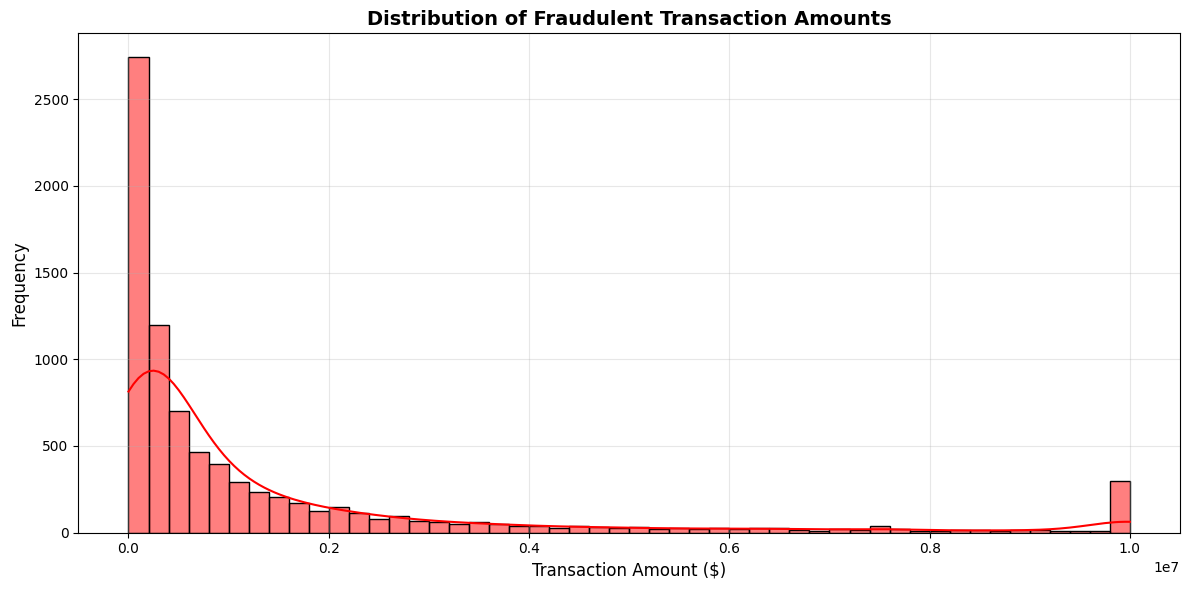

In [ ]:
plt.figure(figsize=(12, 6))

# Filter fraud transactions
fraud_amounts = df[df['isFraud'] == 1]['amount']

# Create histogram
sns.histplot(fraud_amounts, bins=50, kde=True, color='red', edgecolor='black')

plt.title('Distribution of Fraudulent Transaction Amounts', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cell 9: Key Insight - Distribution Plot

Description:
Interpretation of the distribution plot.

In [ ]:
print("="*50)
print("KEY INSIGHT - Distribution Plot")
print("="*50)
print("""
The distribution of fraudulent transaction amounts shows:
1. Most fraud transactions range from $100,000 to $500,000
2. There are extreme outliers exceeding $5,000,000
3. The distribution is right-skewed (long tail of large amounts)

Conclusion: Fraudsters target large transactions, making them easier to detect.
""")

KEY INSIGHT - Distribution Plot

The distribution of fraudulent transaction amounts shows:
1. Most fraud transactions range from $100,000 to $500,000
2. There are extreme outliers exceeding $5,000,000
3. The distribution is right-skewed (long tail of large amounts)

Conclusion: Fraudsters target large transactions, making them easier to detect.



Cell 9: Time-Series Plot - Fraud Over Time

Description:
Track fraud frequency across time steps

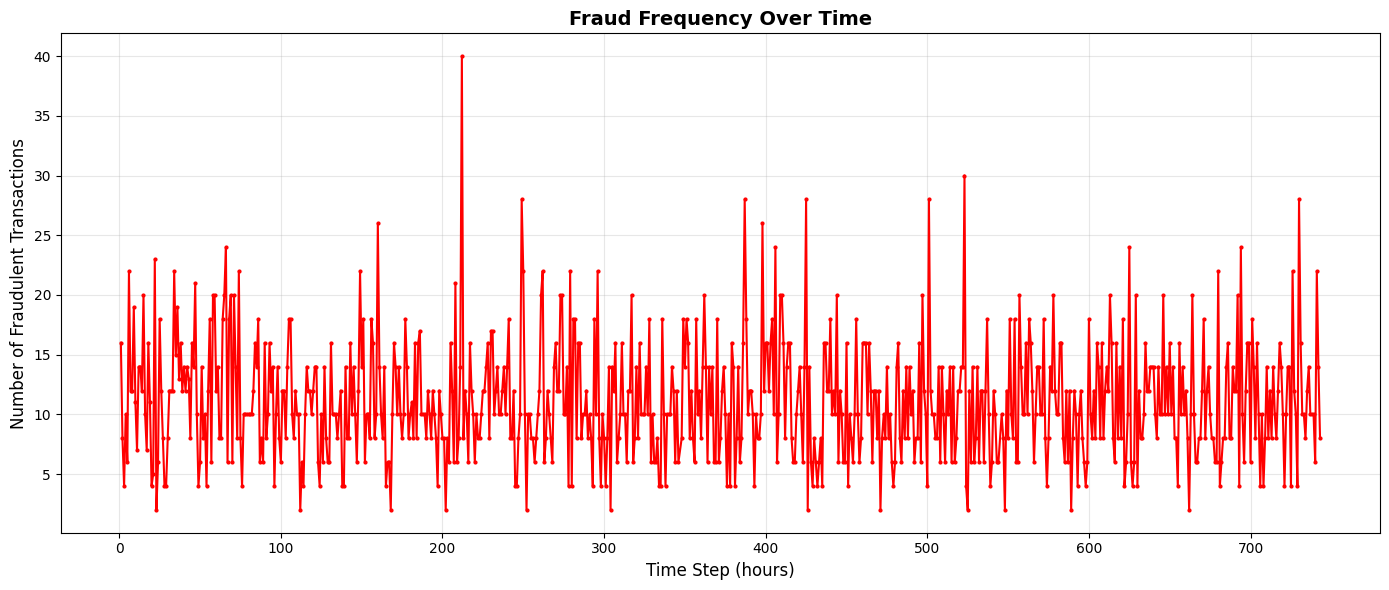

In [ ]:
plt.figure(figsize=(14, 6))

# Group fraud by time step
fraud_over_time = df[df['isFraud'] == 1].groupby('step').size()

plt.plot(fraud_over_time.index, fraud_over_time.values,
         color='red', linewidth=1.5, marker='o', markersize=2)

plt.title('Fraud Frequency Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (hours)', fontsize=12)
plt.ylabel('Number of Fraudulent Transactions', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cell 11: Key Insight - Time-Series Plot

Description:
Interpretation of the time-series plot

In [ ]:
print("="*50)
print("KEY INSIGHT - Time-Series Plot")
print("="*50)
print("""
Fraud occurs consistently across all time steps without a specific peak hour.
This indicates:
1. Fraudsters operate 24/7
2. No specific time-based pattern
3. Real-time detection systems are essential

Conclusion: Time-based heuristics alone are insufficient for fraud detection.
""")

KEY INSIGHT - Time-Series Plot

Fraud occurs consistently across all time steps without a specific peak hour.
This indicates:
1. Fraudsters operate 24/7
2. No specific time-based pattern
3. Real-time detection systems are essential

Conclusion: Time-based heuristics alone are insufficient for fraud detection.



Cell 12: Top Fraud Transaction Types

Description:
Identify which transaction types are most targeted by fraudsters.

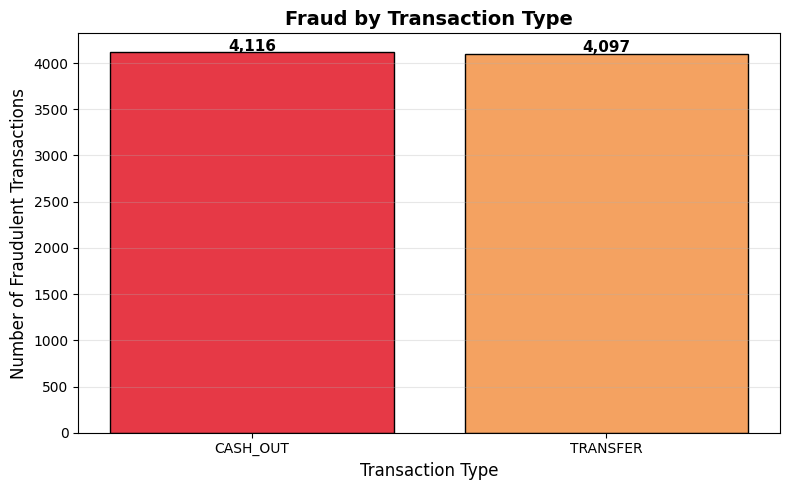


KEY INSIGHT - Transaction Types

Fraud occurs ONLY in:
- CASH_OUT (4,116 cases)
- TRANSFER (4,097 cases)

PAYMENT, CASH_IN, and DEBIT transactions have ZERO fraud.



In [ ]:
plt.figure(figsize=(8, 5))

fraud_types = df[df['isFraud'] == 1]['type'].value_counts()
colors = ['#E63946', '#F4A261']

bars = plt.bar(fraud_types.index, fraud_types.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, fraud_types.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.title('Fraud by Transaction Type', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("KEY INSIGHT - Transaction Types")
print("="*50)
print("""
Fraud occurs ONLY in:
- CASH_OUT (4,116 cases)
- TRANSFER (4,097 cases)

PAYMENT, CASH_IN, and DEBIT transactions have ZERO fraud.
""")

Cell 13: Fraud "Fingerprint" Output

Description:
Extract the final fraud fingerprint for the integration phase.

In [ ]:
print("="*60)
print("🎯 FRAUD FINGERPRINT - Final Output for Integration")
print("="*60)

# Calculate key metrics
avg_fraud_amount = df[df['isFraud'] == 1]['amount'].mean()
median_fraud_amount = df[df['isFraud'] == 1]['amount'].median()
top_fraud_type = df[df['isFraud'] == 1]['type'].value_counts().index[0]
fraud_percentage = (len(df[df['isFraud'] == 1]) / len(df)) * 100

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    FRAUD FINGERPRINT                           │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 1. Fraud Percentage:           {fraud_percentage:.4f}%                          │
│ 2. Average Fraud Amount:       ${avg_fraud_amount:,.2f}                         │
│ 3. Median Fraud Amount:        ${median_fraud_amount:,.2f}                      │
│ 4. Most Targeted Type:         {top_fraud_type}                                 │
│ 5. Detection Rate:             {df[df['isFlaggedFraud'] == 1].shape[0]} flagged │
└─────────────────────────────────────────────────────────────────┘
""")

print("\n✅ FRAUD FILE ANALYSIS COMPLETE")

🎯 FRAUD FINGERPRINT - Final Output for Integration

┌─────────────────────────────────────────────────────────────────┐
│                    FRAUD FINGERPRINT                           │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 1. Fraud Percentage:           0.1291%                          │
│ 2. Average Fraud Amount:       $1,467,967.30                         │
│ 3. Median Fraud Amount:        $441,423.44                      │
│ 4. Most Targeted Type:         CASH_OUT                                 │
│ 5. Detection Rate:             16 flagged │
└─────────────────────────────────────────────────────────────────┘


✅ FRAUD FILE ANALYSIS COMPLETE
